In [13]:
# Import necessary libraries
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
# Load the pre-trained model as specified in the assignment
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
# 1. Define 10 sentences across 3 topics: Cricket, Cooking, and Cybersecurity
sentences = [
    "The batsman smashed a powerful six over the boundary ropes.",
    "The bowler delivered a perfect yorker to dismiss the captain.",
    "Cricket is a sport played with a bat, ball, and eleven players.",
    "Whisk the eggs and sugar together until the mixture is frothy.",
    "Slow-cook the marinated lamb for four hours until it is tender.",
    "Sauté the finely chopped onions in olive oil until golden brown.",
    "Add a pinch of sea salt and black pepper to enhance the flavor.",
    "Always enable multi-factor authentication to secure your accounts.",
    "Phishing attacks often use deceptive links to steal user data.",
    "A robust firewall is essential to prevent unauthorized network access."
]


In [16]:
# 2. Generate Embeddings
embeddings = model.encode(sentences)

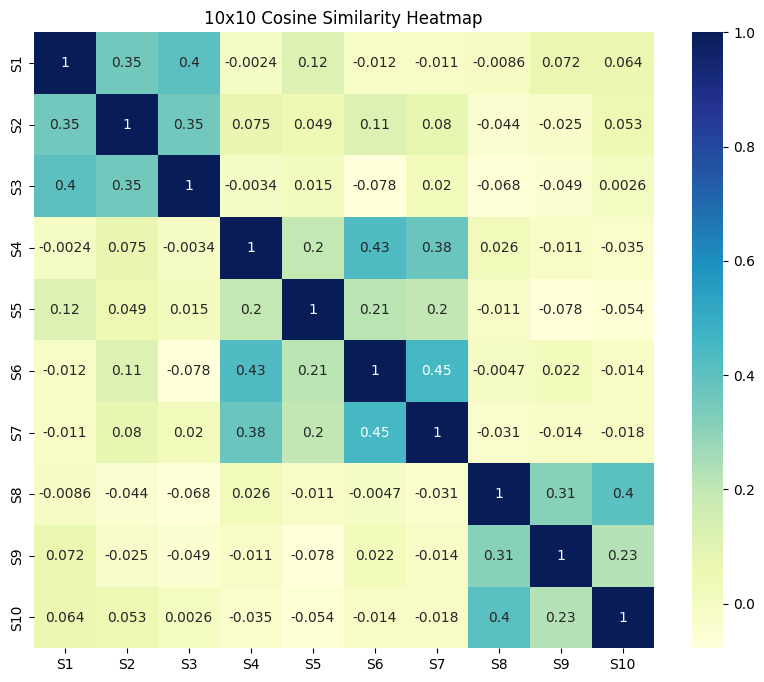

In [17]:
# 3. Compute and display a 10x10 Cosine Similarity Matrix as a heatmap
cosine_scores = util.cos_sim(embeddings, embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores.numpy(), annot=True, cmap='YlGnBu',
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)])
plt.title("10x10 Cosine Similarity Heatmap")
plt.show()

In [18]:
# 4. Search Query Task
new_query = "The bowler took three wickets in one over"
query_embedding = model.encode(new_query)

# Find top 2 most similar sentences
search_results = util.semantic_search(query_embedding, embeddings, top_k=2)

print(f"Query: {new_query}")
print("-" * 30)
for hit in search_results[0]:
    print(f"Score: {hit['score']:.4f} | Sentence: {sentences[hit['corpus_id']]}")


Query: The bowler took three wickets in one over
------------------------------
Score: 0.5413 | Sentence: The bowler delivered a perfect yorker to dismiss the captain.
Score: 0.4961 | Sentence: The batsman smashed a powerful six over the boundary ropes.
